# BCI Competition IV 2a — Real-Data CRNN-DF Controlled Ablation

This notebook is a **controlled real-data debugging/reproduction stage** for the Zhang et al. (2023) subject-independent CRNN-DF pipeline.

### Changes in this version

1. **Continuous 1–38 Hz filtering before epoch extraction** instead of filtering each 4-s epoch independently.
2. **Training-only z-score normalization** with true standard deviation.
3. **Strict LOSO fold isolation** for preprocessing and FBCSP/LASSO.
4. **Deterministic experiment resets** so the three A01 ablations start from the same model initialization and same mini-batch order.
5. Three controlled A01 variants:
   - CRNN only (`lambda=0`)
   - current paper-style fixed centroid shift (`lambda=0.1`)
   - dynamic-center variant (`lambda=0.1`) that recomputes class centers from the current feature space after each epoch before applying the paper's centroid-shift step.
6. No target-subject E data is used during model fitting.
7. Full 9-subject LOSO remains disabled until the A01 ablation is understood.

The 2023 paper reports CRNN-DF at 63.52 ± 10.70% and the 3,000-sample FBGAN configuration at 72.82 ± 10.44% on BCI IV-2a. These are **9-subject means**, not a single-subject target.

In [1]:
# ============================================================
# CELL 1 — IMPORTS / GLOBAL CONFIGURATION
# ============================================================
# If needed, run:
# %pip install -U mne scipy scikit-learn pandas matplotlib seaborn h5py

import os
import re
import copy
import json
import math
import time
import random
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.io as sio
import scipy.signal as signal
from scipy.linalg import eigh

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LassoCV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    cohen_kappa_score,
)
from sklearn.manifold import TSNE

import mne

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

SEED = 42

def reset_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

reset_global_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("MNE:", mne.__version__)
print("Device:", device)

FS = 250
N_CHANNELS = 22
N_TIME = 1000
TRIAL_SECONDS = 4.0
CLASS_NAMES = ["Left Hand", "Right Hand", "Feet", "Tongue"]
EVENT_TO_CLASS = {769: 0, 770: 1, 771: 2, 772: 3}
EVAL_UNKNOWN_EVENT = 783

DATA_ROOT_CANDIDATES = [
    Path.cwd() / "BCI IV-2a",
    Path.cwd() / "BCI_IV-2a",
    Path.cwd() / "BCI IV 2a",
    Path.cwd().parent / "BCI IV-2a",
    Path("/Users") / os.getenv("USER", "") / "MtechProj" / "BCI IV-2a",
    Path("/content/BCI IV-2a"),
]

def find_dataset_root(candidates=DATA_ROOT_CANDIDATES):
    for p in candidates:
        if p.exists() and (p / "A01T.gdf").exists():
            return p.resolve()
    for base in [Path.cwd(), Path.home()]:
        try:
            for p in base.rglob("A01T.gdf"):
                if p.parent.name.lower().replace("_", " ") in {"bci iv-2a", "bci iv 2a"}:
                    return p.parent.resolve()
        except Exception:
            pass
    return None

DATA_ROOT = find_dataset_root()
print("DATA_ROOT =", DATA_ROOT)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not locate A01T.gdf. Set DATA_ROOT manually."
    )
TRUE_LABEL_ROOT = DATA_ROOT / "true_labels"

PyTorch: 2.10.0
MNE: 1.11.0
Device: mps
DATA_ROOT = /Users/ashokvarmabevara/MtechProj/BCI IV-2a


In [2]:

# ============================================================
# CELL 2 — DATASET FOLDER AUDIT
# ============================================================

gdf_files = sorted(DATA_ROOT.glob("A*.gdf"))
mat_files = sorted(DATA_ROOT.glob("A*.mat"))

print("Dataset directory:", DATA_ROOT)
print("GDF files:", len(gdf_files))
print("MAT files:", len(mat_files))
print("true_labels exists:", TRUE_LABEL_ROOT.exists())

for p in gdf_files:
    print(f"{p.name:10s}  {p.stat().st_size/1024/1024:7.2f} MB")

print("\nRequired GDF files:")
for sid in range(1, 10):
    for sess in ["T", "E"]:
        p = DATA_ROOT / f"A{sid:02d}{sess}.gdf"
        print(p.name, "OK" if p.exists() else "MISSING")

print("\nTrue-label files, if present:")
if TRUE_LABEL_ROOT.exists():
    for p in sorted(TRUE_LABEL_ROOT.rglob("*")):
        if p.is_file():
            print(" ", p.relative_to(TRUE_LABEL_ROOT))
else:
    print("  No true_labels directory found.")
    print("  The official BCI site provides the true labels for evaluation sets.")


Dataset directory: /Users/ashokvarmabevara/MtechProj/BCI IV-2a
GDF files: 18
MAT files: 9
true_labels exists: True
A01E.gdf      32.77 MB
A01T.gdf      32.08 MB
A02E.gdf      31.61 MB
A02T.gdf      32.30 MB
A03E.gdf      30.95 MB
A03T.gdf      31.51 MB
A04E.gdf      31.49 MB
A04T.gdf      28.67 MB
A05E.gdf      32.43 MB
A05T.gdf      32.73 MB
A06E.gdf      31.79 MB
A06T.gdf      32.39 MB
A07E.gdf      32.11 MB
A07T.gdf      32.49 MB
A08E.gdf      32.81 MB
A08T.gdf      32.21 MB
A09E.gdf      32.20 MB
A09T.gdf      32.12 MB

Required GDF files:
A01T.gdf OK
A01E.gdf OK
A02T.gdf OK
A02E.gdf OK
A03T.gdf OK
A03E.gdf OK
A04T.gdf OK
A04E.gdf OK
A05T.gdf OK
A05E.gdf OK
A06T.gdf OK
A06E.gdf OK
A07T.gdf OK
A07E.gdf OK
A08T.gdf OK
A08E.gdf OK
A09T.gdf OK
A09E.gdf OK

True-label files, if present:
  A01E.mat
  A01T.mat
  A02E.mat
  A02T.mat
  A03E.mat
  A03T.mat
  A04E.mat
  A04T.mat
  A05E.mat
  A05T.mat
  A06E.mat
  A06T.mat
  A07E.mat
  A07T.mat
  A08E.mat
  A08T.mat
  A09E.mat
  A09T.mat
  tru

In [3]:

# ============================================================
# CELL 3 — ROBUST TRUE-LABEL LOADER FOR E-SESSIONS
# ============================================================

def _flatten_numeric_arrays(obj):
    out = []
    if isinstance(obj, np.ndarray):
        if np.issubdtype(obj.dtype, np.number):
            out.append(np.asarray(obj).ravel())
        elif obj.dtype == object:
            for item in obj.ravel():
                out.extend(_flatten_numeric_arrays(item))
    elif isinstance(obj, dict):
        for v in obj.values():
            out.extend(_flatten_numeric_arrays(v))
    elif isinstance(obj, (list, tuple)):
        for item in obj:
            out.extend(_flatten_numeric_arrays(item))
    return out

def _candidate_label_files(subject_id):
    # Example subject_id: "A01"
    candidates = []
    if not TRUE_LABEL_ROOT.exists():
        return candidates

    for p in TRUE_LABEL_ROOT.rglob("*"):
        if not p.is_file():
            continue
        name = p.name.lower()
        full = str(p).lower()
        if subject_id.lower() in name or subject_id.lower() in full:
            if p.suffix.lower() in {".mat", ".txt", ".csv", ".tsv", ".npy"}:
                candidates.append(p)

    # Also allow files named only A01E...
    candidates.sort()
    return candidates

def _load_numeric_label_vector(path):
    suffix = path.suffix.lower()

    if suffix in {".txt", ".csv", ".tsv"}:
        arr = np.loadtxt(path, delimiter="," if suffix == ".csv" else None)
        return np.asarray(arr).ravel()

    if suffix == ".npy":
        return np.asarray(np.load(path)).ravel()

    if suffix == ".mat":
        mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
        candidates = _flatten_numeric_arrays(mat)

        valid = []
        for arr in candidates:
            arr = np.asarray(arr).ravel()
            if arr.size >= 100:
                # Typical BCI 2a class labels are 1..4.
                vals = np.unique(arr[np.isfinite(arr)])
                if vals.size > 0 and np.all(np.isin(vals, [0, 1, 2, 3, 4])):
                    valid.append(arr)

        if not valid:
            raise ValueError(f"No plausible 1..4 label vector found in {path}")

        valid.sort(key=lambda x: x.size, reverse=True)
        return valid[0]

    raise ValueError(f"Unsupported label file: {path}")

def load_true_labels_for_eval(subject_id, expected_n=288):
    files = _candidate_label_files(subject_id)
    if not files:
        raise FileNotFoundError(
            f"No true label file found for {subject_id}E inside {TRUE_LABEL_ROOT}. "
            "Download the official BCI IV-2a evaluation labels and place them there."
        )

    last_error = None
    for path in files:
        try:
            y = _load_numeric_label_vector(path)
            y = np.asarray(y).astype(int)

            # Some label files can contain 0..3; others 1..4.
            vals = set(np.unique(y).tolist())
            if vals.issubset({0,1,2,3}) and len(vals) == 4:
                y = y
            elif vals.issubset({1,2,3,4}):
                y = y - 1
            else:
                continue

            if len(y) == expected_n:
                print(f"{subject_id}E labels loaded from {path.name}: {len(y)}")
                return y

        except Exception as e:
            last_error = e

    raise RuntimeError(
        f"Could not find a valid {expected_n}-label vector for {subject_id}E. "
        f"Candidates: {[p.name for p in files]}. Last error: {last_error}"
    )


In [4]:
# ============================================================
# CELL 4 — GDF READER: CONTINUOUS FILTERING BEFORE EPOCHING
# ============================================================

def _parse_event_code(description):
    s = str(description)
    nums = re.findall(r"\d+", s)
    return int(nums[-1]) if nums else None

def _fill_continuous_nans(eeg):
    eeg = np.asarray(eeg, dtype=np.float32).copy()
    for ch in range(eeg.shape[0]):
        row = eeg[ch]
        bad = ~np.isfinite(row)
        if bad.any():
            finite = row[np.isfinite(row)]
            fill = float(np.mean(finite)) if finite.size else 0.0
            row[bad] = fill
    return eeg

def _continuous_bandpass_1_38(eeg, fs=FS, order=5):
    sos = signal.butter(
        order,
        [1.0, 38.0],
        btype="bandpass",
        fs=fs,
        output="sos",
    )
    # Filtering the full continuous session first avoids applying filtfilt edge
    # transients separately to each 4-second trial.
    return signal.sosfiltfilt(sos, eeg, axis=-1).astype(np.float32)

def read_gdf_trials(path, session_type):
    path = Path(path)
    raw = mne.io.read_raw_gdf(str(path), preload=True, verbose="ERROR")
    data = raw.get_data()

    if data.shape[0] < 22:
        raise ValueError(f"{path.name}: expected >=22 channels, got {data.shape[0]}")
    sfreq = float(raw.info["sfreq"])
    if not np.isclose(sfreq, FS):
        raise ValueError(f"{path.name}: expected {FS} Hz, got {sfreq}")

    # First 22 channels are EEG; EOG is ignored for this paper reproduction.
    eeg = _fill_continuous_nans(data[:22])
    eeg = _continuous_bandpass_1_38(eeg, fs=FS, order=5)

    events, event_id = mne.events_from_annotations(raw, verbose="ERROR")
    code_by_mne_id = {}
    for desc, eid in event_id.items():
        code = _parse_event_code(desc)
        if code is not None:
            code_by_mne_id[eid] = code

    selected_codes = set(EVENT_TO_CLASS.keys()) if session_type.upper() == "T" else {EVAL_UNKNOWN_EVENT}
    selected = []
    for sample, _, event_eid in events:
        code = code_by_mne_id.get(event_eid)
        if code in selected_codes:
            selected.append((int(sample), int(code)))

    if not selected:
        for ann in raw.annotations:
            onset_sample = int(round(float(ann["onset"]) * sfreq))
            code = _parse_event_code(ann["description"])
            if code in selected_codes:
                selected.append((onset_sample, code))

    selected.sort(key=lambda z: z[0])

    X, y, meta_rows = [], [], []
    for trial_idx, (cue_sample, code) in enumerate(selected):
        start = cue_sample
        stop = start + N_TIME
        if start < 0 or stop > eeg.shape[1]:
            continue
        X.append(eeg[:, start:stop].astype(np.float32))
        if session_type.upper() == "T":
            y.append(EVENT_TO_CLASS[code])
        meta_rows.append({
            "file": path.name,
            "session": session_type.upper(),
            "trial_in_file": trial_idx,
            "cue_sample": cue_sample,
            "event_code": code,
        })

    X = np.asarray(X, dtype=np.float32)
    y_out = np.asarray(y, dtype=np.int64) if session_type.upper() == "T" else None
    meta = pd.DataFrame(meta_rows)
    return X, y_out, meta

In [5]:

# ============================================================
# CELL 5 — LOAD ALL 9 SUBJECTS / BOTH SESSIONS
# ============================================================

def load_subject(subject_num):
    sid = f"A{subject_num:02d}"

    # Training/calibration session: labels are present in GDF events.
    X_T, y_T, meta_T = read_gdf_trials(DATA_ROOT / f"{sid}T.gdf", "T")

    # Evaluation session: cue onset is unknown, labels come from official true labels.
    X_E, _, meta_E = read_gdf_trials(DATA_ROOT / f"{sid}E.gdf", "E")
    y_E = load_true_labels_for_eval(sid, expected_n=len(X_E))

    if len(X_T) != 288:
        print(f"WARNING {sid}T: expected 288 trials, got {len(X_T)}")
    if len(X_E) != 288:
        print(f"WARNING {sid}E: expected 288 trials, got {len(X_E)}")

    # Merge sessions in file order: T then E.
    X = np.concatenate([X_T, X_E], axis=0)
    y = np.concatenate([y_T, y_E], axis=0)

    meta_T["subject"] = sid
    meta_E["subject"] = sid
    meta_T["source_session"] = "T"
    meta_E["source_session"] = "E"

    meta = pd.concat([meta_T, meta_E], ignore_index=True)

    assert X.shape[1:] == (N_CHANNELS, N_TIME)
    assert len(X) == len(y)

    return X, y, meta

subjects = {}
load_log = []

for s in range(1, 10):
    t0 = time.time()
    Xs, ys, ms = load_subject(s)
    subjects[f"A{s:02d}"] = {"X": Xs, "y": ys, "meta": ms}
    load_log.append({
        "subject": f"A{s:02d}",
        "trials": len(Xs),
        "shape": str(Xs.shape),
        "seconds": round(time.time() - t0, 2),
    })
    print(
        f"A{s:02d}: X={Xs.shape}, class_counts={np.bincount(ys)}, "
        f"time={load_log[-1]['seconds']}s"
    )

load_df = pd.DataFrame(load_log)
display(load_df)

X_all = np.stack([subjects[f"A{s:02d}"]["X"] for s in range(1, 10)], axis=0)
y_all = np.stack([subjects[f"A{s:02d}"]["y"] for s in range(1, 10)], axis=0)

print("\nFINAL STACKED DATA")
print("X_all:", X_all.shape)  # expected (9, 576, 22, 1000)
print("y_all:", y_all.shape)  # expected (9, 576)


A01E labels loaded from A01E.mat: 288
A01: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.09s
A02E labels loaded from A02E.mat: 288
A02: X=(576, 22, 1000), class_counts=[144 144 144 144], time=0.98s
A03E labels loaded from A03E.mat: 288
A03: X=(576, 22, 1000), class_counts=[144 144 144 144], time=0.97s
A04E labels loaded from A04E.mat: 288
A04: X=(576, 22, 1000), class_counts=[144 144 144 144], time=0.93s
A05E labels loaded from A05E.mat: 288
A05: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.01s
A06E labels loaded from A06E.mat: 288
A06: X=(576, 22, 1000), class_counts=[144 144 144 144], time=0.98s
A07E labels loaded from A07E.mat: 288
A07: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.0s
A08E labels loaded from A08E.mat: 288
A08: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.0s
A09E labels loaded from A09E.mat: 288
A09: X=(576, 22, 1000), class_counts=[144 144 144 144], time=1.0s


,subject,trials,shape,seconds
0,A01,576,"(576, 22, 1000)",1.09
1,A02,576,"(576, 22, 1000)",0.98
2,A03,576,"(576, 22, 1000)",0.97
3,A04,576,"(576, 22, 1000)",0.93
4,A05,576,"(576, 22, 1000)",1.01
5,A06,576,"(576, 22, 1000)",0.98
6,A07,576,"(576, 22, 1000)",1.00
7,A08,576,"(576, 22, 1000)",1.00
8,A09,576,"(576, 22, 1000)",1.00



FINAL STACKED DATA
X_all: (9, 576, 22, 1000)
y_all: (9, 576)


In [6]:
# ============================================================
# CELL 6 — REAL-DATA PREPROCESSOR (1–38 ALREADY DONE CONTINUOUSLY)
# ============================================================

class EEGPreprocessorReal:
    def __init__(self, fs=250):
        self.fs = fs
        self.bands = [
            (1,4), (4,8), (8,12), (12,16), (16,20),
            (20,24), (24,28), (28,32), (32,35), (35,38)
        ]
        self.mu = None
        self.sigma = None

    def _fill_nans(self, X):
        X = np.asarray(X, dtype=np.float32).copy()
        ch_mean = np.nanmean(X, axis=(0,2), keepdims=True)
        ch_mean = np.where(np.isfinite(ch_mean), ch_mean, 0.0)
        inds = ~np.isfinite(X)
        if inds.any():
            X[inds] = np.broadcast_to(ch_mean, X.shape)[inds]
        return X

    def bandpass(self, X, low, high, order=5):
        sos = signal.butter(
            order,
            [low, high],
            btype="bandpass",
            fs=self.fs,
            output="sos"
        )
        return signal.sosfiltfilt(sos, X, axis=-1).astype(np.float32)

    def fit(self, X_train_1_38):
        X = self._fill_nans(X_train_1_38)
        # Statistics are estimated only from the training subjects.
        self.mu = np.mean(X, axis=(0,2), keepdims=True).astype(np.float32)
        self.sigma = (np.std(X, axis=(0,2), keepdims=True) + 1e-6).astype(np.float32)
        return X

    def transform(self, X_1_38):
        if self.mu is None:
            raise RuntimeError("Call fit() first.")
        X = self._fill_nans(X_1_38)
        X_norm = (X - self.mu) / self.sigma

        X_fb = np.stack(
            [self.bandpass(X_norm, lo, hi, order=5) for lo, hi in self.bands],
            axis=1
        )
        return X_norm.astype(np.float32), X_fb.astype(np.float32)

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

In [7]:

# ============================================================
# CELL 7 — FBCSP + LASSO (FIT ONLY ON TRAINING SUBJECTS)
# ============================================================

class FBCSPLassoReal:
    def __init__(self, m_filters=4, max_iter=5000, random_state=42):
        self.m_filters = m_filters
        self.max_iter = max_iter
        self.random_state = random_state
        self.W_full = None
        self.selected_indices = None
        self.Var = None

    @staticmethod
    def _norm_cov(x):
        c = x @ x.T
        tr = np.trace(c)
        if not np.isfinite(tr) or tr <= 1e-12:
            return np.eye(x.shape[0], dtype=np.float64) / x.shape[0]
        return c / tr

    def fit(self, X_fb, y):
        n, n_bands, n_ch, _ = X_fb.shape
        classes = np.arange(4)

        W_chunks = []
        feature_chunks = []

        for b in range(n_bands):
            Xb = X_fb[:, b]

            band_filters = []
            for c in classes:
                Xc = Xb[y == c]
                Xr = Xb[y != c]

                Rc = np.mean([self._norm_cov(x) for x in Xc], axis=0)
                Rr = np.mean([self._norm_cov(x) for x in Xr], axis=0)

                # Small shrinkage for numerical stability on real EEG.
                eps = 1e-6
                Rc = Rc + eps * np.eye(n_ch)
                Rr = Rr + eps * np.eye(n_ch)

                vals, vecs = eigh(Rc, Rr)
                order = np.argsort(vals)[::-1]
                vecs = vecs[:, order]

                # Paper keeps 4 largest eigenvectors for each OVR subfilter.
                band_filters.append(vecs[:, :self.m_filters])

            W_b = np.hstack(band_filters)  # (22,16)
            W_chunks.append(W_b)

            # Candidate features for this band: log-variance of the 16 CSP outputs.
            Zb = np.einsum("cf,nct->nft", W_b, Xb)
            var = np.var(Zb, axis=-1)
            power = var / (np.sum(var, axis=1, keepdims=True) + 1e-8)
            feat_b = np.log(power + 1e-8)
            feature_chunks.append(feat_b)

        self.W_full = np.stack(W_chunks, axis=0)  # (10,22,16)
        features = np.concatenate(feature_chunks, axis=1)  # (N,160)

        # LASSO on the training fold only.
        # For multiclass labels, the paper uses penalized regression to select
        # informative sparse CSP dimensions. A CV alpha is more stable than a
        # fixed arbitrary alpha on real data.
        lasso = LassoCV(
            alphas=np.logspace(-4, -1, 25),
            cv=5,
            max_iter=self.max_iter,
            n_jobs=-1,
            random_state=self.random_state,
        )
        lasso.fit(features, y.astype(float))

        coef_abs = np.abs(lasso.coef_)
        selected = np.flatnonzero(coef_abs > 1e-8)

        if len(selected) == 0:
            # Stable fallback: keep the 16 strongest candidates.
            selected = np.argsort(coef_abs)[-16:]
            selected = np.unique(selected)

        self.selected_indices = selected
        self.Var = int(len(selected))

        print(
            f"FBCSP+LASSO: 160 candidates -> {self.Var} selected sparse filters"
        )
        return self

    def transform(self, X_fb):
        if self.selected_indices is None:
            raise RuntimeError("Call fit() first.")

        n = X_fb.shape[0]
        all_features = []

        for b in range(X_fb.shape[1]):
            W_b = self.W_full[b]
            Zb = np.einsum("cf,nct->nft", W_b, X_fb[:, b])
            var = np.var(Zb, axis=-1)
            power = var / (np.sum(var, axis=1, keepdims=True) + 1e-8)
            feat_b = np.log(power + 1e-8)
            all_features.append(feat_b)

        features = np.concatenate(all_features, axis=1)
        return features[:, self.selected_indices]

    def transform_signal(self, X_norm):
        # Apply the selected filters to the composite 1–38 Hz signal.
        # Each selected filter index maps to a band and one of 16 OVR CSP columns.
        outputs = []

        for flat_idx in self.selected_indices:
            b = int(flat_idx // (4 * self.m_filters))
            j = int(flat_idx % (4 * self.m_filters))
            w = self.W_full[b][:, j]
            z = np.einsum("c,nct->nt", w, X_norm)
            outputs.append(z)

        return np.stack(outputs, axis=1).astype(np.float32)  # (N,Var,T)


In [8]:
# ============================================================
# CELL 8 — CRNN-DF + CONTROLLED CENTER-LOSS VARIANTS
# ============================================================

class CRNNDF(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        self.conv = nn.Conv2d(1, 45, kernel_size=(22,45), stride=(1,1))
        self.bn = nn.BatchNorm2d(45)
        self.dropout1 = nn.Dropout(0.5)
        self.pool = nn.MaxPool2d(kernel_size=(1,75), stride=(1,10))
        self.lstm1 = nn.LSTM(input_size=45, hidden_size=64, batch_first=True)
        self.dropout2 = nn.Dropout(0.5)
        self.lstm2 = nn.LSTM(input_size=64, hidden_size=64, batch_first=True)
        self.dropout3 = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.bn(self.conv(x)))
        x = self.dropout1(x)
        x = self.pool(x)
        x = x.squeeze(2).permute(0,2,1)
        x, _ = self.lstm1(x)
        x = self.dropout2(x)
        x, _ = self.lstm2(x)
        x = self.dropout3(x)
        features = x[:, -1, :]
        logits = self.fc(features)
        return logits, features

class DiscriminativeCenterLoss(nn.Module):
    """
    Three modes:
      none         : lambda=0, no center term
      fixed_shift  : initialize centroids once, then apply paper-style
                     centroid separation every 15 epochs
      dynamic      : initialize centroids once, update class centers from
                     the current training feature space after each epoch,
                     then apply the same centroid-shift rule every 15 epochs.

    The dynamic mode is an engineering variant for ablation, not a claim of
    exact source-code replication of the paper.
    """
    def __init__(self, num_classes=4, feat_dim=64, alpha=0.02,
                 lambda_cen=0.1, mode="fixed_shift"):
        super().__init__()
        self.num_classes = num_classes
        self.feat_dim = feat_dim
        self.alpha = alpha
        self.lambda_cen = lambda_cen
        self.mode = mode
        self.register_buffer("centroids", torch.zeros(num_classes, feat_dim))
        self.ce = nn.CrossEntropyLoss()

    @torch.no_grad()
    def initialize_from_features(self, features, y):
        for c in range(self.num_classes):
            m = (y == c)
            if m.any():
                self.centroids[c].copy_(features[m].mean(dim=0))

    @torch.no_grad()
    def update_from_features(self, features, y):
        for c in range(self.num_classes):
            m = (y == c)
            if m.any():
                self.centroids[c].copy_(features[m].mean(dim=0))

    @torch.no_grad()
    def shift_centroids(self):
        center = self.centroids.mean(0, keepdim=True)
        delta = self.centroids - center
        norm = torch.linalg.norm(delta, dim=1, keepdim=True).clamp_min(1e-8)
        self.centroids += self.alpha * delta / norm

    def forward(self, features, y, logits):
        ce = self.ce(logits, y)
        if self.lambda_cen <= 0.0 or self.mode == "none":
            cen = torch.zeros((), device=features.device)
            return ce, ce, cen
        centers = self.centroids[y]
        cen = ((features - centers) ** 2).sum(dim=1).mean()
        total = ce + self.lambda_cen * cen
        return total, ce, cen

In [9]:
# ============================================================
# CELL 9 — DETERMINISTIC TRAINING / EVALUATION UTILITIES
# ============================================================

def make_loader(X, y, batch_size=32, shuffle=True, seed=SEED):
    Xt = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
    yt = torch.tensor(y, dtype=torch.long)
    ds = torch.utils.data.TensorDataset(Xt, yt)
    gen = torch.Generator()
    gen.manual_seed(seed)
    return torch.utils.data.DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        generator=gen if shuffle else None,
        num_workers=0,
        pin_memory=False,
    )

@torch.no_grad()
def extract_all_features(model, X, y, batch_size=128):
    model.eval()
    loader = make_loader(X, y, batch_size=batch_size, shuffle=False)
    feats, labels = [], []
    for xb, yb in loader:
        xb = xb.to(device)
        _, fb = model(xb)
        feats.append(fb.detach().cpu())
        labels.append(yb)
    return torch.cat(feats, dim=0).to(device), torch.cat(labels, dim=0).to(device)

def train_crnn_df(
    X_train,
    y_train,
    X_val=None,
    y_val=None,
    epochs=150,
    batch_size=32,
    lr=1e-4,
    weight_decay=1e-4,
    patience=None,
    center_lambda=0.1,
    center_mode="fixed_shift",
    center_alpha=0.02,
    center_shift_every=15,
    seed=SEED,
):
    # Reset EVERYTHING that controls initialization/order for each ablation.
    reset_global_seed(seed)

    init_loader = make_loader(X_train, y_train, batch_size=128, shuffle=False)
    train_loader = make_loader(X_train, y_train, batch_size=batch_size, shuffle=True, seed=seed)

    model = CRNNDF(num_classes=4).to(device)

    center_loss = DiscriminativeCenterLoss(
        num_classes=4,
        feat_dim=64,
        alpha=center_alpha,
        lambda_cen=center_lambda,
        mode=center_mode,
    ).to(device)

    # Initialize centroids once from the untrained feature space.
    init_features, init_labels = extract_all_features(model, X_train, y_train)
    center_loss.initialize_from_features(init_features, init_labels)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running = {"loss": 0.0, "ce": 0.0, "cen": 0.0}
        n_batches = 0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits, feats = model(xb)
            loss, ce, cen = center_loss(feats, yb, logits)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            running["loss"] += float(loss.item())
            running["ce"] += float(ce.item())
            running["cen"] += float(cen.item())
            n_batches += 1

        # Dynamic variant: recalculate centers from current training features.
        if center_mode == "dynamic" and center_lambda > 0:
            current_features, current_labels = extract_all_features(model, X_train, y_train)
            center_loss.update_from_features(current_features, current_labels)

        # Paper-style centroid separation step.
        if center_lambda > 0 and center_mode != "none" and epoch % center_shift_every == 0:
            center_loss.shift_centroids()

        rec = {
            "epoch": epoch,
            "loss": running["loss"] / max(1, n_batches),
            "ce": running["ce"] / max(1, n_batches),
            "cen": running["cen"] / max(1, n_batches),
        }

        if X_val is not None and y_val is not None:
            val_acc = evaluate_model(model, X_val, y_val)["accuracy"]
            rec["val_acc"] = val_acc

        history.append(rec)

        if epoch == 1 or epoch % 10 == 0 or epoch == epochs:
            extra = f" | val={rec['val_acc']*100:.2f}%" if "val_acc" in rec else ""
            print(
                f"Epoch {epoch:03d} | loss={rec['loss']:.4f} | "
                f"CE={rec['ce']:.4f} | CEN={rec['cen']:.4f}{extra}"
            )

    return model, pd.DataFrame(history)

@torch.no_grad()
def evaluate_model(model, X, y):
    model.eval()
    loader = make_loader(X, y, batch_size=128, shuffle=False)
    all_pred, all_feat, all_true = [], [], []
    for xb, yb in loader:
        xb = xb.to(device)
        logits, feats = model(xb)
        all_pred.append(logits.argmax(1).cpu().numpy())
        all_feat.append(feats.cpu().numpy())
        all_true.append(yb.numpy())
    y_pred = np.concatenate(all_pred)
    feats = np.concatenate(all_feat)
    y_true = np.concatenate(all_true)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "kappa": cohen_kappa_score(y_true, y_pred),
        "y_true": y_true,
        "y_pred": y_pred,
        "features": feats,
    }

def plot_fold_result(result, subject_id, title_suffix=""):
    cm = confusion_matrix(result["y_true"], result["y_pred"], labels=np.arange(4))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", cbar=True, ax=axes[0],
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    axes[0].set_title(f"{subject_id} — Confusion Matrix{title_suffix}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")

    feats = result["features"]
    perplexity = min(30, max(5, len(feats)//20))
    z = TSNE(n_components=2, random_state=SEED, perplexity=perplexity, init="pca").fit_transform(feats)
    axes[1].scatter(z[:,0], z[:,1], c=result["y_true"], cmap="viridis", s=14)
    axes[1].set_title(f"{subject_id} — CRNN-DF Feature t-SNE{title_suffix}")
    axes[1].set_xlabel("t-SNE 1")
    axes[1].set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

FBCSP+LASSO: 160 candidates -> 14 selected sparse filters

A01 controlled fold: train (4608, 22, 1000) test (576, 22, 1000) sparse Var 14

################################################################################
CRNN-ONLY
################################################################################
Epoch 001 | loss=1.3886 | CE=1.3886 | CEN=0.0000
Epoch 010 | loss=1.3064 | CE=1.3064 | CEN=0.0000
Epoch 020 | loss=1.1947 | CE=1.1947 | CEN=0.0000
Epoch 030 | loss=1.0777 | CE=1.0777 | CEN=0.0000
Epoch 040 | loss=1.0023 | CE=1.0023 | CEN=0.0000
Epoch 050 | loss=0.9547 | CE=0.9547 | CEN=0.0000
Epoch 060 | loss=0.8740 | CE=0.8740 | CEN=0.0000
Epoch 070 | loss=0.8456 | CE=0.8456 | CEN=0.0000
Epoch 080 | loss=0.7870 | CE=0.7870 | CEN=0.0000
Epoch 090 | loss=0.7767 | CE=0.7767 | CEN=0.0000
Epoch 100 | loss=0.7352 | CE=0.7352 | CEN=0.0000
Epoch 110 | loss=0.6946 | CE=0.6946 | CEN=0.0000
Epoch 120 | loss=0.6729 | CE=0.6729 | CEN=0.0000
Epoch 130 | loss=0.6420 | CE=0.6420 | CEN=0.0000
Epo

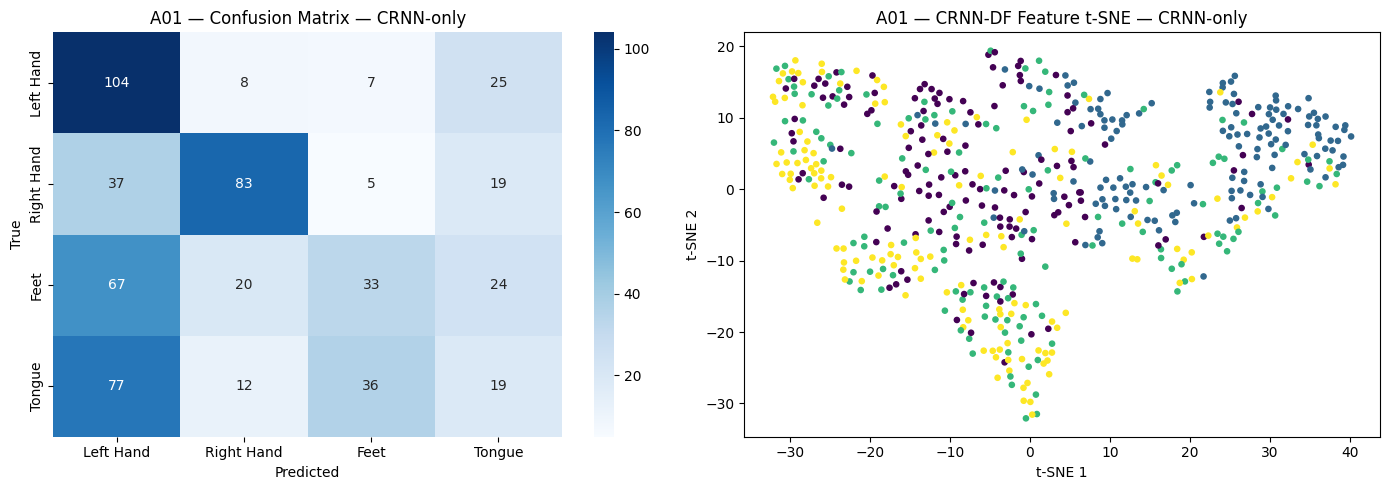


################################################################################
CRNN + FIXED CENTROID SHIFT
################################################################################
Epoch 001 | loss=1.4482 | CE=1.3892 | CEN=0.5903
Epoch 010 | loss=1.4105 | CE=1.3773 | CEN=0.3320
Epoch 020 | loss=1.3186 | CE=1.2426 | CEN=0.7596
Epoch 030 | loss=1.2078 | CE=1.1024 | CEN=1.0537
Epoch 040 | loss=1.1335 | CE=1.0223 | CEN=1.1120
Epoch 050 | loss=1.0722 | CE=0.9543 | CEN=1.1791
Epoch 060 | loss=1.0105 | CE=0.8965 | CEN=1.1404
Epoch 070 | loss=0.9856 | CE=0.8759 | CEN=1.0974
Epoch 080 | loss=0.9511 | CE=0.8374 | CEN=1.1377
Epoch 090 | loss=0.9129 | CE=0.8020 | CEN=1.1092
Epoch 100 | loss=0.8762 | CE=0.7668 | CEN=1.0936
Epoch 110 | loss=0.8436 | CE=0.7348 | CEN=1.0875
Epoch 120 | loss=0.8160 | CE=0.7102 | CEN=1.0579
Epoch 130 | loss=0.8108 | CE=0.7048 | CEN=1.0600
Epoch 140 | loss=0.7642 | CE=0.6556 | CEN=1.0866
Epoch 150 | loss=0.7560 | CE=0.6475 | CEN=1.0858


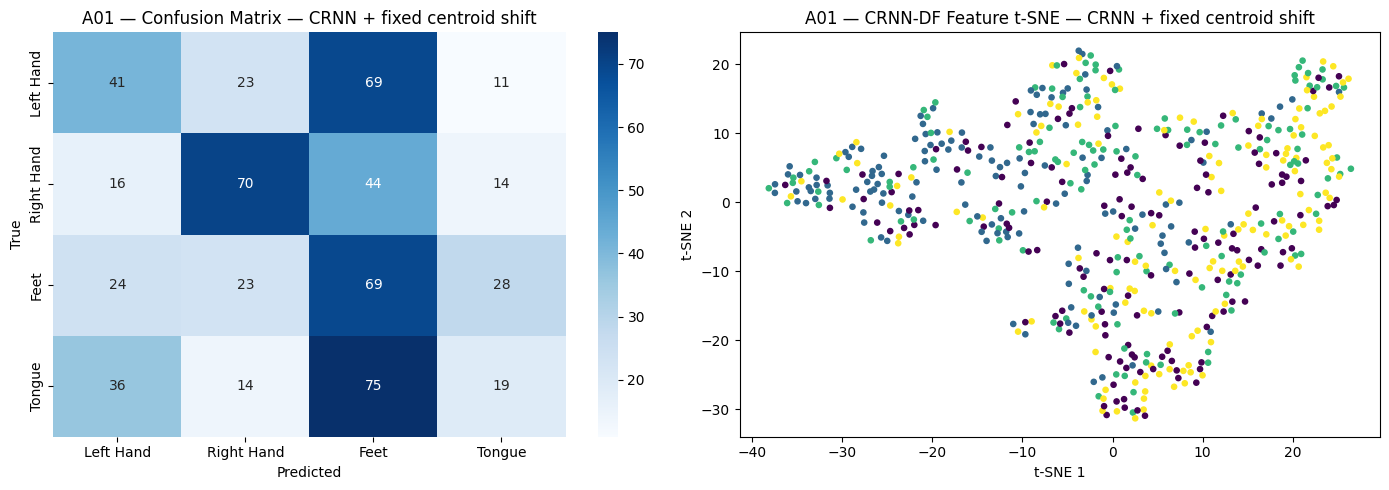


################################################################################
CRNN + DYNAMIC CENTERS
################################################################################
Epoch 001 | loss=1.4482 | CE=1.3892 | CEN=0.5903
Epoch 010 | loss=1.3836 | CE=1.3749 | CEN=0.0864
Epoch 020 | loss=1.2907 | CE=1.2466 | CEN=0.4404
Epoch 030 | loss=1.2152 | CE=1.1572 | CEN=0.5793
Epoch 040 | loss=1.1372 | CE=1.0653 | CEN=0.7190
Epoch 050 | loss=1.0865 | CE=1.0086 | CEN=0.7789
Epoch 060 | loss=1.0247 | CE=0.9449 | CEN=0.7977
Epoch 070 | loss=0.9888 | CE=0.9145 | CEN=0.7426
Epoch 080 | loss=0.9340 | CE=0.8599 | CEN=0.7412
Epoch 090 | loss=0.8988 | CE=0.8261 | CEN=0.7272
Epoch 100 | loss=0.8659 | CE=0.7931 | CEN=0.7282
Epoch 110 | loss=0.8508 | CE=0.7785 | CEN=0.7221
Epoch 120 | loss=0.7942 | CE=0.7248 | CEN=0.6937
Epoch 130 | loss=0.7998 | CE=0.7337 | CEN=0.6614
Epoch 140 | loss=0.7554 | CE=0.6870 | CEN=0.6832
Epoch 150 | loss=0.7348 | CE=0.6690 | CEN=0.6577


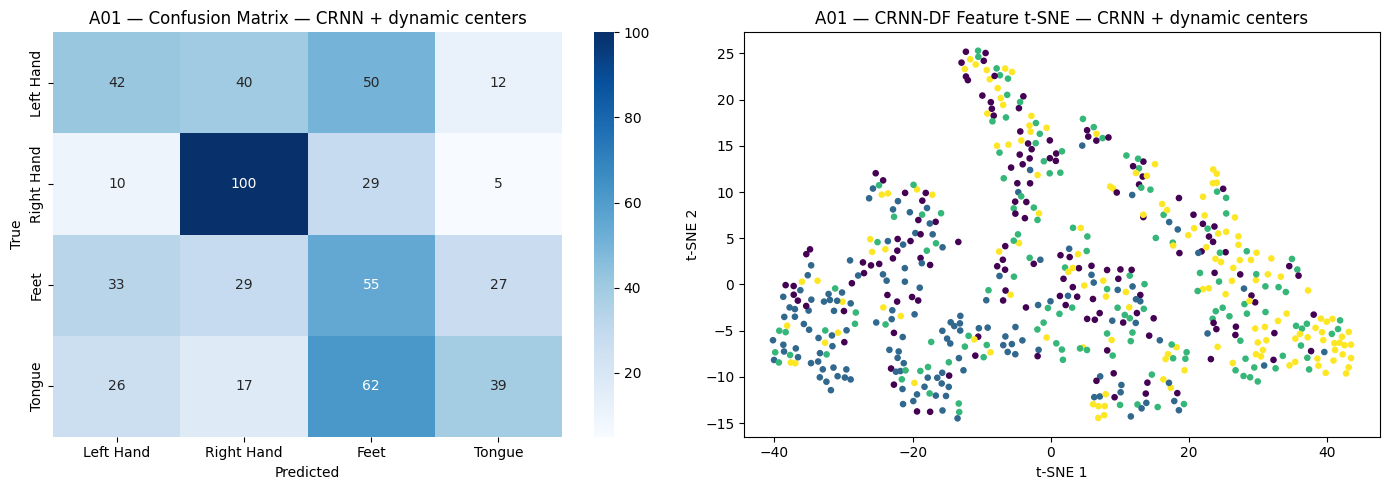


A01 CONTROLLED ABLATION SUMMARY


,variant,center_lambda,center_mode,epochs,test_accuracy,balanced_accuracy,kappa,train_accuracy,test_accuracy_pct,train_accuracy_pct
0,CRNN-only,0.0,none,150,0.414931,0.414931,0.219907,0.588542,41.493056,58.854167
1,CRNN + dynamic centers,0.1,dynamic,150,0.409722,0.409722,0.212963,0.618490,40.972222,61.848958
2,CRNN + fixed centroid shift,0.1,fixed_shift,150,0.345486,0.345486,0.127315,0.616102,34.548611,61.610243


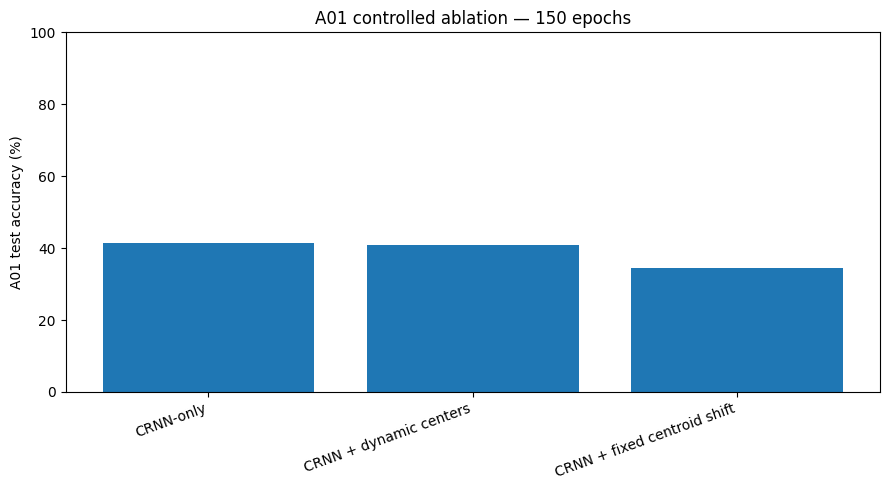

In [10]:
# ============================================================
# CELL 10 — STRICT LOSO FOLD + CONTROLLED A01 ABLATION
# ============================================================

def prepare_fold_data(train_subject_ids, test_subject_id):
    X_train = np.concatenate([subjects[s]["X"] for s in train_subject_ids], axis=0)
    y_train = np.concatenate([subjects[s]["y"] for s in train_subject_ids], axis=0)
    X_test = subjects[test_subject_id]["X"]
    y_test = subjects[test_subject_id]["y"]

    # Continuous 1–38 Hz filtering has already happened in the GDF reader.
    pre = EEGPreprocessorReal(fs=FS)
    pre.fit(X_train)
    X_train_norm, X_train_fb = pre.transform(X_train)
    X_test_norm, X_test_fb = pre.transform(X_test)

    fbcsp = FBCSPLassoReal(m_filters=4)
    fbcsp.fit(X_train_fb, y_train)

    return {
        "preprocessor": pre,
        "fbcsp": fbcsp,
        "X_train": X_train_norm,
        "y_train": y_train,
        "X_train_fb": X_train_fb,
        "X_test": X_test_norm,
        "y_test": y_test,
        "X_test_fb": X_test_fb,
    }

def run_one_subject(
    subject_id,
    epochs=150,
    center_lambda=0.1,
    center_mode="fixed_shift",
    seed=SEED,
    plot=True,
):
    train_subject_ids = [f"A{i:02d}" for i in range(1,10) if f"A{i:02d}" != subject_id]
    print("="*80)
    print(f"STRICT LOSO TEST SUBJECT: {subject_id}")
    print("="*80)
    fold = prepare_fold_data(train_subject_ids, subject_id)
    print(
        "Train:", fold["X_train"].shape,
        "Test:", fold["X_test"].shape,
        "Sparse Var:", fold["fbcsp"].Var
    )

    model, history = train_crnn_df(
        fold["X_train"], fold["y_train"],
        epochs=epochs,
        batch_size=32,
        lr=1e-4,
        weight_decay=1e-4,
        patience=None,
        center_lambda=center_lambda,
        center_mode=center_mode,
        center_alpha=0.02,
        center_shift_every=15,
        seed=seed,
    )

    result = evaluate_model(model, fold["X_test"], fold["y_test"])
    train_result = evaluate_model(model, fold["X_train"], fold["y_train"])
    print(
        f"{subject_id}: TEST Accuracy={result['accuracy']*100:.2f}% | "
        f"Balanced Acc={result['balanced_accuracy']*100:.2f}% | Kappa={result['kappa']:.4f} | "
        f"TRAIN Accuracy={train_result['accuracy']*100:.2f}%"
    )
    if plot:
        plot_fold_result(result, subject_id, title_suffix=f" — {center_mode}")
    return {
        "subject": subject_id,
        "result": result,
        "train_result": train_result,
        "history": history,
        "fold": fold,
        "model": model,
        "center_lambda": center_lambda,
        "center_mode": center_mode,
        "seed": seed,
    }

def run_a01_controlled_ablation(epochs=150, seed=SEED):
    """
    Same A01 fold, same data, same random seed, same optimizer settings.
    Only center-loss configuration changes.
    """
    configs = [
        {"name": "CRNN-only", "lambda": 0.0, "mode": "none"},
        {"name": "CRNN + fixed centroid shift", "lambda": 0.1, "mode": "fixed_shift"},
        {"name": "CRNN + dynamic centers", "lambda": 0.1, "mode": "dynamic"},
    ]

    # Prepare the fold ONCE so every ablation receives identical arrays.
    reset_global_seed(seed)
    train_subject_ids = [f"A{i:02d}" for i in range(1,10) if f"A{i:02d}" != "A01"]
    fold = prepare_fold_data(train_subject_ids, "A01")
    print(
        "\nA01 controlled fold:",
        "train", fold["X_train"].shape,
        "test", fold["X_test"].shape,
        "sparse Var", fold["fbcsp"].Var,
    )

    rows = []
    outputs = {}

    for cfg in configs:
        print("\n" + "#"*80)
        print(cfg["name"].upper())
        print("#"*80)
        reset_global_seed(seed)
        model, history = train_crnn_df(
            fold["X_train"], fold["y_train"],
            epochs=epochs,
            batch_size=32,
            lr=1e-4,
            weight_decay=1e-4,
            patience=None,
            center_lambda=cfg["lambda"],
            center_mode=cfg["mode"],
            center_alpha=0.02,
            center_shift_every=15,
            seed=seed,
        )
        test_result = evaluate_model(model, fold["X_test"], fold["y_test"])
        train_result = evaluate_model(model, fold["X_train"], fold["y_train"])
        rows.append({
            "variant": cfg["name"],
            "center_lambda": cfg["lambda"],
            "center_mode": cfg["mode"],
            "epochs": epochs,
            "test_accuracy": test_result["accuracy"],
            "balanced_accuracy": test_result["balanced_accuracy"],
            "kappa": test_result["kappa"],
            "train_accuracy": train_result["accuracy"],
        })
        outputs[cfg["name"]] = {
            "model": model,
            "history": history,
            "test": test_result,
            "train": train_result,
        }
        plot_fold_result(test_result, "A01", title_suffix=f" — {cfg['name']}")

    summary = pd.DataFrame(rows).sort_values("test_accuracy", ascending=False).reset_index(drop=True)
    print("\nA01 CONTROLLED ABLATION SUMMARY")
    display(summary.assign(
        test_accuracy_pct=lambda d: d.test_accuracy*100,
        train_accuracy_pct=lambda d: d.train_accuracy*100,
    ))

    plt.figure(figsize=(9,5))
    plt.bar(summary["variant"], summary["test_accuracy"]*100)
    plt.ylabel("A01 test accuracy (%)")
    plt.title(f"A01 controlled ablation — {epochs} epochs")
    plt.xticks(rotation=20, ha="right")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

    return summary, outputs, fold

# Run the controlled experiment first.
ABLATION_EPOCHS = 150
a01_summary, a01_outputs, a01_fold = run_a01_controlled_ablation(epochs=ABLATION_EPOCHS, seed=SEED)

In [11]:
# ============================================================
# CELL 11 — FULL 9-SUBJECT STRICT LOSO (RUN AFTER A01 ABLATION)
# ============================================================

RUN_FULL_LOSO = False
LOSO_EPOCHS = 150
SELECTED_CENTER_MODE = "dynamic"      # or "none" / "fixed_shift"
SELECTED_CENTER_LAMBDA = 0.1

if RUN_FULL_LOSO:
    fold_rows = []
    fold_results = []
    for s in range(1, 10):
        sid = f"A{s:02d}"
        out = run_one_subject(
            sid,
            epochs=LOSO_EPOCHS,
            center_lambda=SELECTED_CENTER_LAMBDA,
            center_mode=SELECTED_CENTER_MODE,
            seed=SEED,
            plot=True,
        )
        fold_results.append(out)
        r = out["result"]
        fold_rows.append({
            "subject": sid,
            "accuracy": r["accuracy"],
            "balanced_accuracy": r["balanced_accuracy"],
            "kappa": r["kappa"],
            "train_accuracy": out["train_result"]["accuracy"],
            "sparse_var": out["fold"]["fbcsp"].Var,
        })

    results_df = pd.DataFrame(fold_rows)
    print("\n" + "="*80)
    print("STRICT LOSO SUMMARY")
    print("="*80)
    display(results_df.assign(
        accuracy_pct=lambda d: d.accuracy*100,
        balanced_accuracy_pct=lambda d: d.balanced_accuracy*100,
        train_accuracy_pct=lambda d: d.train_accuracy*100,
    ))
    print(
        f"Mean accuracy = {results_df['accuracy'].mean()*100:.2f}% "
        f"± {results_df['accuracy'].std(ddof=1)*100:.2f}%"
    )
    print(
        f"Mean balanced accuracy = {results_df['balanced_accuracy'].mean()*100:.2f}% "
        f"± {results_df['balanced_accuracy'].std(ddof=1)*100:.2f}%"
    )
    print(
        f"Mean kappa = {results_df['kappa'].mean():.4f} "
        f"± {results_df['kappa'].std(ddof=1):.4f}"
    )
else:
    print("RUN_FULL_LOSO=False — controlled A01 ablation only.")

RUN_FULL_LOSO=False — controlled A01 ablation only.



## Optional FBGAN augmentation track

For the real-data paper-style augmentation experiment, do **not** use the official E-session labels from the held-out test subject to train the classifier.

The original paper reports:
- CRNN-DF without augmentation: **63.52 ± 10.70%**
- 3,000 generated samples: **72.82 ± 10.44%**
- 4,000 generated samples: **72.82 ± 10.94%**

The paper says the 3,000-sample setting is 750 generated samples per class. Table 4 also shows that increasing the number of generated samples is not monotonic for every subject.

This notebook therefore separates:
1. **Strict LOSO** — no target-subject EEG is used for training.
2. **Target-adaptation / FBGAN track** — target-subject labeled data can be used only when the experiment explicitly defines it as adaptation data, and the evaluation session remains separate.

That distinction is essential for an honest comparison.


In [12]:

# ============================================================
# CELL 12 — TARGET-SESSION ADAPTATION SPLIT (OPTIONAL)
# ============================================================
# This cell documents a reproducible adaptation split:
#   - Other 8 subjects: all labeled T+E data
#   - Target subject: T session is adaptation data
#   - Target subject: E session is final evaluation data
#
# This is NOT strict subject-independent LOSO anymore.
# It is useful for reproducing a target-adaptation/FBGAN scenario.

def get_target_adaptation_split(target_subject_id):
    target = subjects[target_subject_id]
    meta = target["meta"]

    target_T_mask = meta["source_session"].values == "T"
    target_E_mask = meta["source_session"].values == "E"

    X_target_T = target["X"][target_T_mask]
    y_target_T = target["y"][target_T_mask]

    X_target_E = target["X"][target_E_mask]
    y_target_E = target["y"][target_E_mask]

    other_ids = [
        sid for sid in subjects.keys()
        if sid != target_subject_id
    ]

    X_other = np.concatenate([subjects[s]["X"] for s in other_ids], axis=0)
    y_other = np.concatenate([subjects[s]["y"] for s in other_ids], axis=0)

    return {
        "X_other": X_other,
        "y_other": y_other,
        "X_target_T": X_target_T,
        "y_target_T": y_target_T,
        "X_target_E": X_target_E,
        "y_target_E": y_target_E,
    }

# Example:
# adapt = get_target_adaptation_split("A01")
# print(adapt["X_other"].shape, adapt["X_target_T"].shape, adapt["X_target_E"].shape)


## What to look for in the A01 ablation

### Desired diagnostic pattern

- **CRNN-only** should establish the raw CRNN generalization level.
- **Fixed centroid shift** should show whether the existing center-loss mechanism helps or hurts.
- **Dynamic centers** should reduce the mismatch between stale centroids and the evolving feature space.

### Important interpretation

Do **not** select a model because it has the highest A01 test score alone. The A01 fold is a debugging probe here. After the ablation, pick the variant based on the whole diagnostic pattern (test accuracy, train/test gap, confusion matrix, and t-SNE), then run strict 9-subject LOSO.

The final paper comparison is a 9-subject mean ± std, not the best individual fold.

## Next stage after A01

1. Run the three-way A01 controlled ablation at 150 epochs.
2. Inspect which variant gives the best generalization **without using A01 as a tuning target beyond this diagnostic stage**.
3. Run all 9 strict LOSO folds with the selected variant.
4. Only after the baseline is stable, enable target-adaptation / FBGAN.

Do not increase the epoch count indefinitely. The previous runs already showed that lower training loss does not guarantee improved unseen-subject accuracy.

In [13]:

# ============================================================
# LATER STAGE — TARGET FBGAN TRAINING + GENERATION
# ============================================================

def _selected_signal_features_torch(W_target, X):
    # W_target: (22,Var), X:(B,1,22,1000)
    # output: (B,1,Var,1000)
    W = W_target.to(device)
    x = X.squeeze(1)
    z = torch.einsum("cv,bct->bvt", W, x)
    return z.unsqueeze(1)


def train_fbgAN_for_target(
    X_target_T_norm,
    y_target_T,
    target_fbcsp,
    n_aug_per_class=750,
    gan_epochs=6,
    gan_batch_size=32,
    gan_lr=1e-4,
):
    """
    Train four class-wise FBGANs from the target subject's T session.

    This is an adaptation experiment:
    target T is used for generating synthetic target data,
    target E is kept for final evaluation.
    """

    if target_fbcsp.Var is None or target_fbcsp.W_full is None:
        raise RuntimeError("Target FBCSP object is not fitted.")

    # Build a single selected spatial-filter matrix from the sparse candidates.
    selected_W = []
    for flat_idx in target_fbcsp.selected_indices:
        b = int(flat_idx // 16)
        j = int(flat_idx % 16)
        selected_W.append(target_fbcsp.W_full[b][:,j])

    W_target = torch.tensor(
        np.stack(selected_W,axis=1),
        dtype=torch.float32,
        device=device
    )

    fake_by_class = []
    fake_labels = []

    for c in range(4):
        idx = np.flatnonzero(y_target_T == c)

        Xc = torch.tensor(
            X_target_T_norm[idx],
            dtype=torch.float32
        ).unsqueeze(1)

        # Sparse filtered target data.
        Zc = _selected_signal_features_torch(W_target,Xc)

        print(
            f"Target class {c}: real={len(idx)} | Var={Zc.shape[2]}"
        )

        G = FBGANGenerator().to(device)
        Dp = FBGANDPhi().to(device)
        Ds = FBGANDPsi(target_fbcsp.Var).to(device)

        loader = torch.utils.data.DataLoader(
            torch.utils.data.TensorDataset(
                Xc,
                Zc.cpu()
            ),
            batch_size=gan_batch_size,
            shuffle=True,
            num_workers=0
        )

        opt_G = optim.Adam(
            G.parameters(),
            lr=gan_lr,
            betas=(0.5,0.999)
        )
        opt_D = optim.Adam(
            list(Dp.parameters()) + list(Ds.parameters()),
            lr=gan_lr,
            betas=(0.5,0.999)
        )
        bce = nn.BCELoss()

        G.train()
        Dp.train()
        Ds.train()

        for ep in range(1,gan_epochs+1):
            d_loss_sum = 0.0
            g_loss_sum = 0.0

            for rx_cpu, rz_cpu in loader:
                rx = rx_cpu.to(device)
                rz = rz_cpu.to(device)
                b = rx.shape[0]

                y_real = torch.ones(b,1,device=device)
                y_fake = torch.zeros(b,1,device=device)

                # -------------------------
                # D update
                # -------------------------
                opt_D.zero_grad(set_to_none=True)

                z = torch.randn(b,1600,device=device)
                fx = G(z)

                fz = _selected_signal_features_torch(
                    W_target,
                    fx
                )

                d_loss = (
                    bce(Dp(rx),y_real) +
                    bce(Dp(fx.detach()),y_fake) +
                    bce(Ds(rz),y_real) +
                    bce(Ds(fz.detach()),y_fake)
                )

                d_loss.backward()
                opt_D.step()

                # -------------------------
                # G update
                # -------------------------
                opt_G.zero_grad(set_to_none=True)

                z = torch.randn(b,1600,device=device)
                fx = G(z)
                fz = _selected_signal_features_torch(
                    W_target,
                    fx
                )

                g_loss = (
                    bce(Dp(fx),y_real) +
                    bce(Ds(fz),y_real)
                )

                g_loss.backward()
                opt_G.step()

                d_loss_sum += float(d_loss.item())
                g_loss_sum += float(g_loss.item())

            if ep == 1 or ep == gan_epochs:
                print(
                    f"  class={c} epoch={ep}/{gan_epochs} "
                    f"D={d_loss_sum/max(1,len(loader)):.4f} "
                    f"G={g_loss_sum/max(1,len(loader)):.4f}"
                )

        # Generate target-specific fake EEG.
        G.eval()
        n_left = n_aug_per_class

        fake_parts = []
        with torch.no_grad():
            for start in range(0,n_left,gan_batch_size):
                n = min(gan_batch_size,n_left-start)
                z = torch.randn(n,1600,device=device)
                fx = G(z)
                fake_parts.append(
                    fx.squeeze(1).cpu().numpy().astype(np.float32)
                )

        fx_np = np.concatenate(fake_parts,axis=0)
        fake_by_class.append(fx_np)
        fake_labels.append(
            np.full(len(fx_np),c,dtype=np.int64)
        )

        del G,Dp,Ds,opt_G,opt_D
        if device.type == "mps":
            torch.mps.empty_cache()

    X_fake = np.concatenate(fake_by_class,axis=0)
    y_fake = np.concatenate(fake_labels,axis=0)

    print(
        "Generated:",
        X_fake.shape,
        "class counts:",
        np.bincount(y_fake)
    )
    return X_fake, y_fake


def run_paper_style_target_adaptation(
    target_subject_id="A01",
    epochs=40,
    n_aug_per_class=750,
    gan_epochs=6,
):
    """
    Paper-style target adaptation:
      - other 8 subjects: all 576 labeled samples each
      - target T: used only to train FBGAN
      - target E: held out for final evaluation
    """

    target = subjects[target_subject_id]
    meta = target["meta"]

    target_T = meta["source_session"].values == "T"
    target_E = meta["source_session"].values == "E"

    X_target_T_raw = target["X"][target_T]
    y_target_T = target["y"][target_T]

    X_target_E_raw = target["X"][target_E]
    y_target_E = target["y"][target_E]

    other_ids = [
        sid for sid in subjects.keys()
        if sid != target_subject_id
    ]

    X_other_raw = np.concatenate(
        [subjects[s]["X"] for s in other_ids],
        axis=0
    )
    y_other = np.concatenate(
        [subjects[s]["y"] for s in other_ids],
        axis=0
    )

    # Fit normalization on OTHER subjects only.
    pre = EEGPreprocessorReal(fs=FS)
    pre.fit(X_other_raw)

    X_other, X_other_fb = pre.transform(X_other_raw)
    X_target_T, X_target_T_fb = pre.transform(X_target_T_raw)
    X_target_E, X_target_E_fb = pre.transform(X_target_E_raw)

    # Target-specific sparse CSP/LASSO for GAN constraint.
    target_fbcsp = FBCSPLassoReal(m_filters=4)
    target_fbcsp.fit(X_target_T_fb,y_target_T)

    print(
        f"\\n{target_subject_id} target sparse Var = "
        f"{target_fbcsp.Var}"
    )

    X_fake, y_fake = train_fbgAN_for_target(
        X_target_T,
        y_target_T,
        target_fbcsp,
        n_aug_per_class=n_aug_per_class,
        gan_epochs=gan_epochs,
    )

    # Train classifier on other-subject real data + generated target data.
    X_cls = np.concatenate([X_other,X_fake],axis=0)
    y_cls = np.concatenate([y_other,y_fake],axis=0)

    print(
        "Classifier training set:",
        X_cls.shape,
        np.bincount(y_cls)
    )

    model, hist = train_crnn_df(
        X_cls,
        y_cls,
        epochs=epochs,
        batch_size=32,
        lr=1e-4,
        weight_decay=1e-4,
        patience=10,
        center_lambda=0.1,
    )

    result = evaluate_model(
        model,
        X_target_E,
        y_target_E
    )

    print(
        f"{target_subject_id} ADAPTATION RESULT: "
        f"{result['accuracy']*100:.2f}% | "
        f"kappa={result['kappa']:.4f}"
    )

    plot_fold_result(result,target_subject_id)

    return {
        "subject":target_subject_id,
        "result":result,
        "history":hist,
        "model":model,
        "fake_X":X_fake,
        "fake_y":y_fake,
        "preprocessor":pre,
        "target_fbcsp":target_fbcsp,
    }
